# Flight Trend & Optimization Analyzer

## 1. Project Overview

This project fetches **real-time global flight data** from the [OpenSky Network API](https://opensky-network.org) and performs data analysis using Object-Oriented Programming (OOP) in Python.

**Core objectives:**
1. Fetch live flight data via REST API
2. Analyze country distribution and airline activity
3. Study velocity and altitude patterns
4. Filter and export data for further use


---
## 2. Environment Setup & Module Import


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.flight_logic import FlightDataAnalyzer, LiveFlightAPI

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
print("[INFO] Environment initialized. Modules and visualization libraries loaded.")


[INFO] Environment initialized. Modules and visualization libraries loaded.


---
## 3. Load Live Data from OpenSky Network API

We use the `LiveFlightAPI` child class (inherits from `FlightDataAnalyzer`) to fetch real-time flight data.
The endpoint `https://opensky-network.org/api/states/all` delivers a dynamic **JSON response**:
- The root object contains `time` (Unix timestamp) and `states` (a 2D array of airborne aircraft state vectors).
- Because `states` contains an array of raw values rather than named keys, our ingestion logic parses the official index positions:
  - `flight[0]`: **icao24** (unique 24-bit transponder hex ID)
  - `flight[1]`: **callsign** (8-character flight identifier)
  - `flight[2]`: **country** (aircraft country of registration)
  - `flight[5]`: **longitude** & `flight[6]`: **latitude** (WGS-84 coordinates)
  - `flight[7]`: **altitude** (barometric altitude in meters)
  - `flight[9]`: **velocity** (ground speed in m/s)
  - `flight[10]`: **heading** (direction of motion in degrees)

The parsed records are converted into a `pandas.DataFrame` and cleaned of missing transponder records.


In [2]:
# Initialize API loader and fetch live flight data
live_api = LiveFlightAPI()

if live_api.fetch_live_flights(limit=500):
    print(f"[SUCCESS] Loaded {len(live_api.df)} live flights from OpenSky Network")
    print(f"Columns: {list(live_api.df.columns)}")
    display(live_api.df.head(10))
else:
    print("[ERROR] Failed to fetch data. Check network connection.")


[SUCCESS] Hamtade och validerade 500 flygningar fran OpenSky Network
[SUCCESS] Loaded 500 live flights from OpenSky Network
Columns: ['icao24', 'callsign', 'country', 'longitude', 'latitude', 'altitude', 'velocity', 'heading']


,icao24,callsign,country,longitude,latitude,altitude,velocity,heading
0,39de4f,TVF539X,France,11.0237,45.4582,11879.58,252.54,103.67
1,ae1fa5,72150,United States,-115.2015,36.2166,NaN,0.00,258.75
2,39de4e,TVF431J,France,8.3656,53.3696,11597.64,228.45,225.18
3,a3b886,N339PC,United States,-73.1665,44.3185,883.92,32.39,122.68
4,ab1644,UAL1219,United States,-87.2549,42.1976,4937.76,203.04,60.06
5,80162d,AXB815,India,73.4922,15.1541,10058.40,239.13,298.11
6,e8027d,LPE2390,Chile,-76.4167,-8.6691,11277.60,232.76,11.09
7,a1abea,NGF7522,United States,-119.3977,47.1980,2674.62,96.71,76.78
8,39de4b,TVF36UQ,France,11.0803,44.1199,11582.40,215.88,303.73
9,39de4a,TVF8231,France,8.5340,44.4571,11597.64,231.23,321.14


---
## 4. Feature 1: Country Distribution Analysis

Which countries have the most airborne flights right now?


=== Top 10 Countries by Live Flight Count ===
  United States: 245 flights
  India: 26 flights
  Hungary: 25 flights
  Sweden: 25 flights
  Chile: 20 flights
  France: 18 flights
  Canada: 17 flights
  Austria: 17 flights
  Germany: 15 flights
  Greece: 13 flights


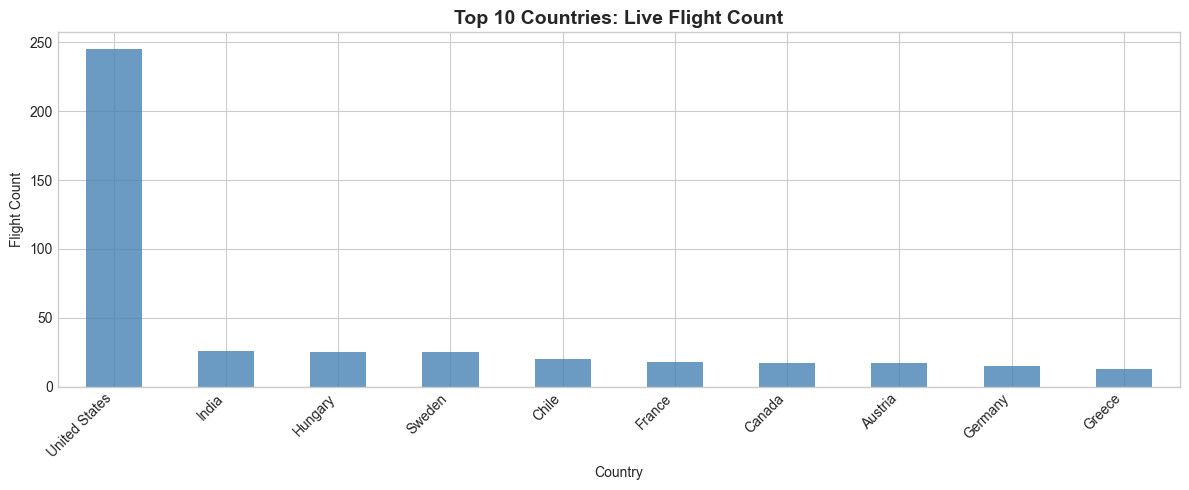

In [3]:
# Top 10 countries by live flight count
country_stats = live_api.df["country"].value_counts().head(10)

print("=== Top 10 Countries by Live Flight Count ===")
for country, count in country_stats.items():
    print(f"  {country}: {count} flights")

# Bar chart visualization
plt.figure(figsize=(12, 5))
country_stats.plot(kind="bar", color="steelblue", alpha=0.8)
plt.title("Top 10 Countries: Live Flight Count", fontsize=14, fontweight="bold")
plt.xlabel("Country")
plt.ylabel("Flight Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


---
## 5. Feature 2: Velocity & Altitude Analysis

Analyze flight speed and altitude patterns across countries.


In [4]:
# Compute velocity and altitude stats by country
valid_flights = live_api.df.dropna(subset=["velocity", "altitude"])

vel_stats = valid_flights.groupby("country").agg(
    flight_count=("icao24", "count"),
    avg_velocity=("velocity", "mean"),
    avg_altitude=("altitude", "mean"),
    max_velocity=("velocity", "max")
).reset_index()

vel_stats["avg_velocity"] = vel_stats["avg_velocity"].round(2)
vel_stats["avg_altitude"] = vel_stats["avg_altitude"].round(2)
vel_stats["max_velocity"] = vel_stats["max_velocity"].round(2)

top_vel = vel_stats.sort_values("flight_count", ascending=False).head(10)
print("=== Top 10 Countries: Velocity & Altitude Stats ===")
display(top_vel)


=== Top 10 Countries: Velocity & Altitude Stats ===


,country,flight_count,avg_velocity,avg_altitude,max_velocity
26,United States,219,133.30,4638.39,269.18
11,Hungary,25,220.62,9484.16,276.15
12,India,25,192.19,7290.82,252.38
22,Sweden,20,191.86,6911.72,275.62
6,Chile,17,201.12,8305.35,249.39
5,Canada,16,114.18,3772.38,266.08
8,France,16,224.31,10954.70,256.47
2,Austria,15,212.11,8586.22,256.98
21,Spain,12,211.28,8166.10,260.93
3,Brazil,12,145.54,5761.36,285.67


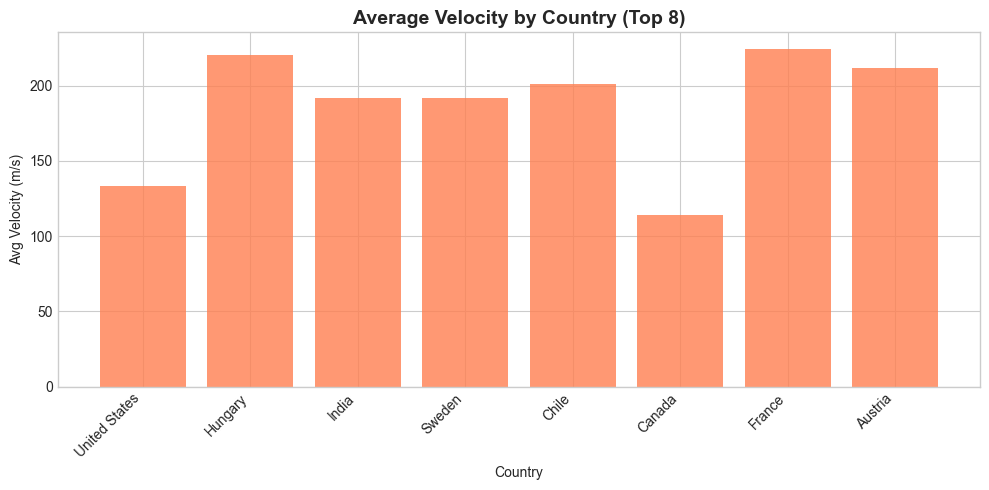

In [5]:
# Bar chart: average velocity by country
plt.figure(figsize=(10, 5))
top_countries = vel_stats.sort_values("flight_count", ascending=False).head(8)
plt.bar(top_countries["country"], top_countries["avg_velocity"], alpha=0.8, color="coral")
plt.title("Average Velocity by Country (Top 8)", fontsize=14, fontweight="bold")
plt.xlabel("Country")
plt.ylabel("Avg Velocity (m/s)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


---
## 6. For-loop: Detailed Flight Summary by Country

Use explicit `for` loops to iterate and print detailed stats for each top country.


In [6]:
# For-loop: print detailed summary for top countries
top_n = 5
country_counts = live_api.df["country"].value_counts().head(top_n)

print(f"\n{'='*60}")
print(f"  Top {top_n} Countries - Detailed Flight Summary")
print(f"{'='*60}")

for country, count in country_counts.items():
    subset = live_api.df[live_api.df["country"] == country]
    avg_vel = subset["velocity"].mean() if not subset["velocity"].isna().all() else 0
    avg_alt = subset["altitude"].mean() if not subset["altitude"].isna().all() else 0
    print(f"\nCountry: {country}")
    print(f"  Total flights: {count}")
    print(f"  Avg velocity: {avg_vel:.2f} m/s")
    print(f"  Avg altitude: {avg_alt:.2f} m")

print(f"\n{'='*60}")



  Top 5 Countries - Detailed Flight Summary

Country: United States
  Total flights: 245
  Avg velocity: 119.98 m/s
  Avg altitude: 4638.39 m

Country: India
  Total flights: 26
  Avg velocity: 187.90 m/s
  Avg altitude: 7290.82 m

Country: Hungary
  Total flights: 25
  Avg velocity: 220.62 m/s
  Avg altitude: 9484.16 m

Country: Sweden
  Total flights: 25
  Avg velocity: 154.25 m/s
  Avg altitude: 6911.72 m

Country: Chile
  Total flights: 20
  Avg velocity: 171.02 m/s
  Avg altitude: 8305.35 m



---
## 7. For-loop: Count Flights by Airline (Callsign)

Count how many flights each airline (callsign) currently has in the air.


In [7]:
# For-loop: count flights by callsign
airline_counts = {}
grouped = live_api.df.groupby("callsign")

for airline_name, group in grouped:
    if airline_name and airline_name.strip() and airline_name != "N/A":
        airline_counts[airline_name] = len(group)

sorted_airlines = dict(sorted(airline_counts.items(), key=lambda x: x[1], reverse=True))

print(f"\n{'='*60}")
print("  Top Airlines by Active Flight Count")
print(f"{'='*60}")

count = 0
for airline, flights in sorted_airlines.items():
    if count >= 10:
        break
    print(f"  {airline}: {flights} flights")
    count += 1

print(f"{'='*60}\n")



  Top Airlines by Active Flight Count
  13400R3C: 1 flights
  636491: 1 flights
  72150: 1 flights
  AAL1717: 1 flights
  AAL1744: 1 flights
  AAL1943: 1 flights
  AAL2584: 1 flights
  AAL2661: 1 flights
  AAL2718: 1 flights
  AAL3284: 1 flights



---
## 8. Filter by Country

Filter live flights for a specific country and analyze distribution.


=== US Flights (245 total) ===


,icao24,callsign,country,longitude,latitude,altitude,velocity,heading
1,ae1fa5,72150,United States,-115.2015,36.2166,NaN,0.00,258.75
3,a3b886,N339PC,United States,-73.1665,44.3185,883.92,32.39,122.68
4,ab1644,UAL1219,United States,-87.2549,42.1976,4937.76,203.04,60.06
7,a1abea,NGF7522,United States,-119.3977,47.1980,2674.62,96.71,76.78
15,a3ebbc,N3516P,United States,-122.6505,43.6807,7315.20,127.04,351.15
16,ab6fdd,AAL2661,United States,-117.0457,33.9700,2613.66,143.49,292.34
17,a60529,N4871V,United States,-120.6129,35.2211,198.12,43.41,301.43
22,a39be7,,United States,-74.0306,45.6781,NaN,0.19,278.44
25,a5f840,N484JC,United States,-122.9448,38.5133,1196.34,95.40,16.28
26,a46216,N3815P,United States,-90.1188,30.0800,373.38,65.20,137.88


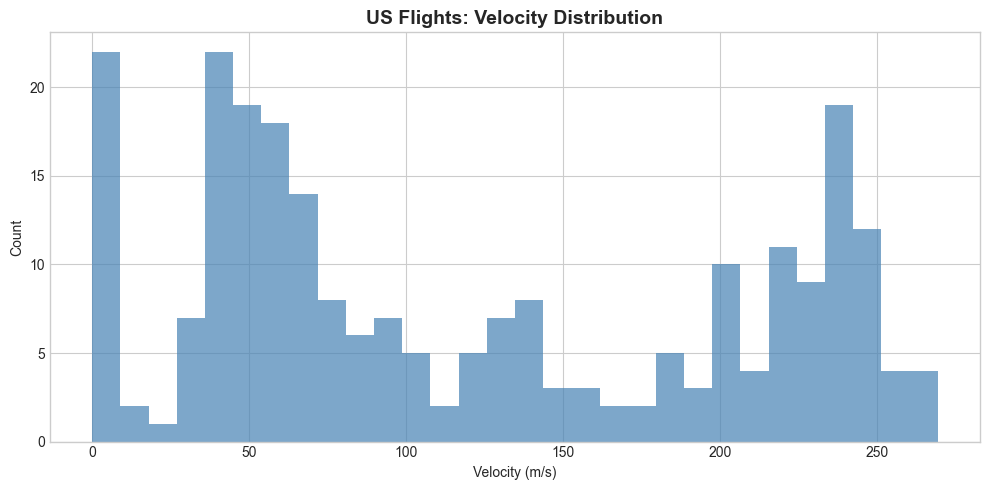

In [8]:
# Filter flights for United States
us_flights = live_api.get_flights_by_country("United States")

if not us_flights.empty:
    print(f"=== US Flights ({len(us_flights)} total) ===")
    display(us_flights.head(10))

    # Velocity distribution histogram
    plt.figure(figsize=(10, 5))
    us_flights["velocity"].dropna().hist(bins=30, color="steelblue", alpha=0.7)
    plt.title("US Flights: Velocity Distribution", fontsize=14, fontweight="bold")
    plt.xlabel("Velocity (m/s)")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()
else:
    print("[WARNING] No US flights found in current data")


---
## 9. Data Export to CSV

Save the fetched live data to a CSV file for external use.


In [14]:
# Export live flight data to CSV
output_file = "live_flights_data.csv"
if live_api.export_cleaned_data(output_filepath=output_file):
    print(f"[SUCCESS] Exported {len(live_api.df)} records to '{output_file}'")
else:
    print("[ERROR] Export failed")


[SUCCESS] Exporterade 500 rader till 'live_flights_data.csv'
[SUCCESS] Exported 500 records to 'live_flights_data.csv'


In [15]:
live_api.test_error_handling()

[TEST] Stage 11: Testing robust error handling:
[WARNING] Ingen data tillganglig att exportera.
  1. Tom data export test -> Klarade felfritt
[WARNING] Ingen data laddad att filtrera.
  2. Ogiltig landsokning test -> Klarade felfritt
